Lutas REALIZADO: 3498 | Período: 2009-2024
Decisivas: 3444 | Title fights: 157

[Q1] Spearman (year vs duration, non-title): rho=0.090, p=2.634e-07, n=3284

[Q2] Qui-quadrado pre/post-2020: chi2=47.98, p=2.155e-10, V de Cramer=0.118, n=3444

[Q3] Classes analisadas: 10
                       n    mean   std  median
weight_class_clean                            
Heavyweight          510  188.71  6.01  187.96
Light Heavyweight    426  186.75  5.56  185.42
Middleweight         623  183.55  5.08  182.88
Welterweight         904  181.14  4.90  180.34
Lightweight          961  177.37  4.78  177.80
Catchweight          560  176.70  7.29  177.80
Featherweight       1079  173.99  4.74  172.72
Bantamweight         558  171.15  4.56  170.18
Flyweight            342  165.66  4.45  165.10
Strawweight           65  161.93  3.78  162.56

[Q4] Resultados por classe:
            group   n  win_rate  ci_low  ci_high  p_value  p_adjusted  significant
      Catchweight 222    0.5991  0.5335   0.6614   0.0

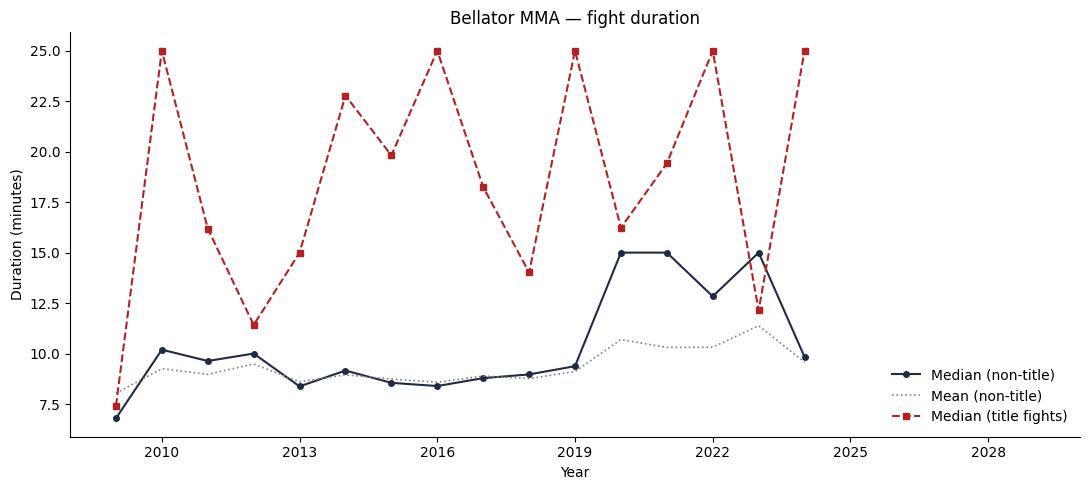

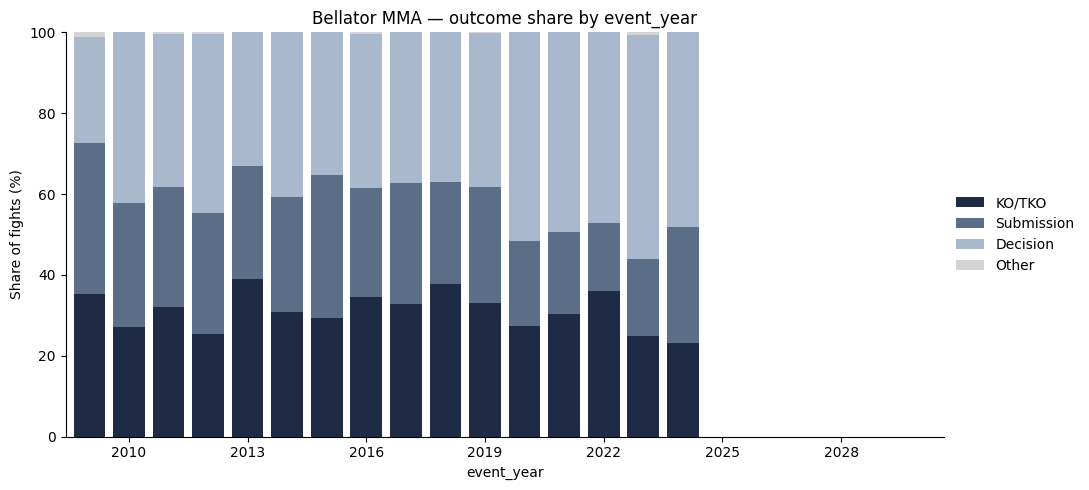

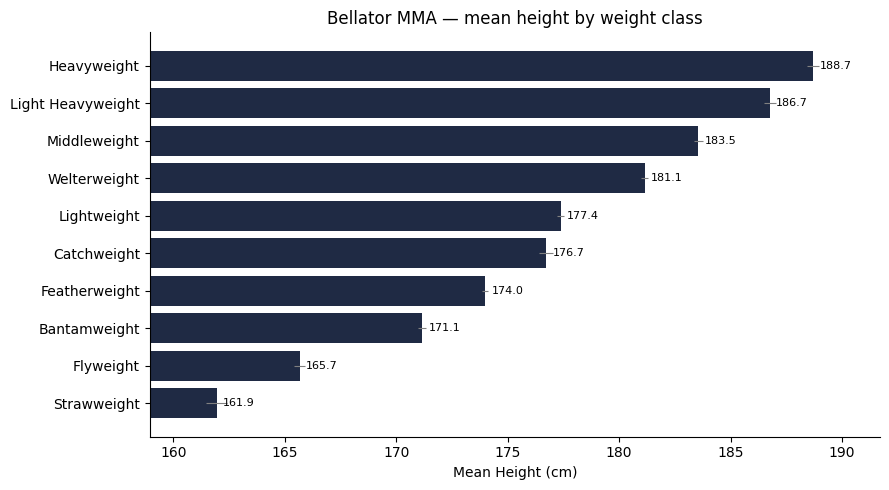

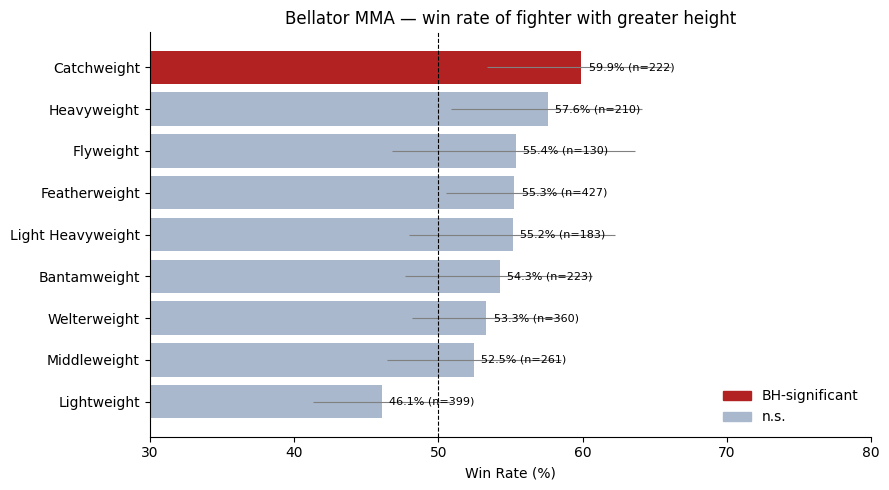

In [1]:
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
from scipy import stats
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm


DATA_DIR = '/kaggle/input/datasets/leandroiber/bellator-mma-complete-dataset'
CSV_PATH = f'{DATA_DIR}/clean_sherdog_bellator.csv'
JSON_PATH = f'{DATA_DIR}/bellator_win_title_data.json'


def temporal_aggregation(df, time_col, value_col, group_col=None,
                         agg_funcs=('median', 'mean'), trend_test=True):
    funcs = list(agg_funcs) + ['count', 'std']
    if group_col is None:
        agg = df.groupby(time_col)[value_col].agg(funcs)
    else:
        agg = df.groupby([time_col, group_col])[value_col].agg(funcs).unstack()

    out = {'aggregation': agg}
    if trend_test:
        clean = df[[time_col, value_col]].dropna()
        if len(clean) > 3:
            rho, p = stats.spearmanr(clean[time_col], clean[value_col])
            out['spearman'] = {'rho': rho, 'p_value': p, 'n': len(clean)}
    return out


def categorical_composition_over_time(df, time_col, category_col,
                                      split_point=None, normalize=True):
    counts = df.groupby([time_col, category_col]).size().unstack(fill_value=0)
    proportions = counts.div(counts.sum(axis=1), axis=0) if normalize else counts

    out = {'proportions': proportions, 'counts': counts}

    if split_point is not None:
        before = df[df[time_col] < split_point][category_col].value_counts()
        after = df[df[time_col] >= split_point][category_col].value_counts()
        contingency = pd.DataFrame({'before': before, 'after': after}).fillna(0)
        chi2, p, dof, _ = stats.chi2_contingency(contingency)
        n = contingency.sum().sum()
        cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape) - 1)))
        out['regime_test'] = {
            'chi2': chi2, 'p_value': p, 'dof': dof,
            'cramers_v': cramers_v, 'n': int(n),
            'contingency': contingency
        }
    return out


def group_descriptive(df, group_col, value_col, min_n=5):
    g = df.dropna(subset=[group_col, value_col]).groupby(group_col)[value_col]
    out = g.agg(['count', 'mean', 'std', 'median',
                 lambda x: x.quantile(0.25),
                 lambda x: x.quantile(0.75)])
    out.columns = ['n', 'mean', 'std', 'median', 'q25', 'q75']
    out['iqr'] = out['q75'] - out['q25']
    out = out[out['n'] >= min_n]
    return out.sort_values('mean', ascending=False)


def paired_advantage_test(df, group_col, attr_a_col, attr_b_col,
                          winner_is_a_col=None,
                          min_n=30, mc_method='fdr_bh', alpha=0.05):
    results = []
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=[attr_a_col, attr_b_col]).copy()
        if winner_is_a_col is not None:
            sub = sub.dropna(subset=[winner_is_a_col])
            a_won = sub[winner_is_a_col].astype(bool)
        else:
            a_won = pd.Series(True, index=sub.index)

        sub = sub[sub[attr_a_col] != sub[attr_b_col]]
        a_won = a_won.loc[sub.index]
        n = len(sub)

        if n < min_n:
            results.append({'group': group, 'n': n, 'underpowered': True})
            continue

        a_greater = sub[attr_a_col] > sub[attr_b_col]
        greater_won = (a_greater & a_won) | (~a_greater & ~a_won)
        wins = int(greater_won.sum())

        ci_low, ci_high = stats.binomtest(wins, n).proportion_ci(method='wilson')
        p_value = stats.binomtest(wins, n, p=0.5, alternative='two-sided').pvalue

        results.append({
            'group': group, 'n': n, 'win_rate': wins / n,
            'ci_low': ci_low, 'ci_high': ci_high,
            'p_value': p_value, 'underpowered': False
        })

    res = pd.DataFrame(results)
    res['p_adjusted'] = np.nan
    res['significant'] = False
    res['underpowered'] = res['underpowered'].astype(bool)

    valid = ~res['underpowered']
    if valid.sum() > 0:
        _, p_adj, _, _ = multipletests(res.loc[valid, 'p_value'],
                                       method=mc_method, alpha=alpha)
        res.loc[valid, 'p_adjusted'] = p_adj
        res.loc[valid, 'significant'] = p_adj < alpha
    return res.sort_values('win_rate', ascending=False, na_position='last')


def continuous_advantage_logit(df, group_col, diff_cols, target_col,
                               covariates=None, min_n=50):
    rows = []
    cols = list(diff_cols) + (covariates or [])
    for group, sub in df.groupby(group_col):
        sub = sub.dropna(subset=cols + [target_col])
        if len(sub) < min_n:
            continue
        X = sm.add_constant(sub[cols])
        y = sub[target_col].astype(int)
        try:
            m = sm.Logit(y, X).fit(disp=0)
            for c in cols:
                rows.append({
                    'group': group, 'predictor': c, 'n': len(sub),
                    'coef': m.params[c],
                    'odds_ratio': np.exp(m.params[c]),
                    'p_value': m.pvalues[c],
                    'or_ci_low': np.exp(m.conf_int().loc[c, 0]),
                    'or_ci_high': np.exp(m.conf_int().loc[c, 1]),
                    'pseudo_r2': m.prsquared
                })
        except Exception as e:
            rows.append({'group': group, 'error': str(e)})
    return pd.DataFrame(rows)


def load_bellator():
    df = pd.read_csv(CSV_PATH)
    df = df[df['event_status'] == 'REALIZADO'].copy()
    df['event_date'] = pd.to_datetime(df['event_date'], utc=True, errors='coerce')
    df['event_year'] = df['event_date'].dt.year

    def time_to_min(row):
        try:
            m, s = map(int, str(row['time']).split(':'))
            r = int(row['round_num'])
            if r < 1:
                return np.nan
            return (r - 1) * 5 + m + s / 60
        except (ValueError, TypeError):
            return np.nan
    df['duration_min'] = df.apply(time_to_min, axis=1)

    def bucket_method(m):
        if pd.isna(m):
            return np.nan
        m = m.lower()
        if 'submission' in m:
            return 'Submission'
        if 'ko' in m or 'tko' in m:
            return 'KO/TKO'
        if 'decision' in m:
            return 'Decision'
        return 'Other'
    df['method_bucket'] = df['method'].apply(bucket_method)

    df['weight_class_clean'] = df['weight_class'].apply(
        lambda x: 'Catchweight' if pd.notna(x) and re.search(r'Catch', str(x), re.I) else x
    )

    df['decisive'] = df['fighter_1_result'] == 'win'

    with open(JSON_PATH) as f:
        title_data = json.load(f)
    title_map = {}
    for k, v in title_data.items():
        key = (v.get('event_date'), v.get('fighter_1'), v.get('fighter_2'))
        title_map[key] = v.get('is_title_fight', False)
    df['_date_str'] = df['event_date'].dt.strftime('%Y-%m-%d')
    df['is_title_fight'] = df.apply(
        lambda r: title_map.get((r['_date_str'], r['fighter_1'], r['fighter_2']), False),
        axis=1
    )
    df = df.drop(columns=['_date_str'])
    return df


def q1_duration_over_time(df, x_max=2030):
    non_title = df[~df['is_title_fight'] & df['decisive']]
    title = df[df['is_title_fight'] & df['decisive']]

    nt_res = temporal_aggregation(non_title, 'event_year', 'duration_min')
    t_res = temporal_aggregation(title, 'event_year', 'duration_min', trend_test=False)

    fig, ax = plt.subplots(figsize=(11, 5))
    nt_agg = nt_res['aggregation']
    ax.plot(nt_agg.index, nt_agg['median'], '-o', color='#1f2a44',
            label='Median (non-title)', markersize=4)
    ax.plot(nt_agg.index, nt_agg['mean'], ':', color='gray',
            label='Mean (non-title)', linewidth=1.2)
    if len(t_res['aggregation']) > 0:
        t_agg = t_res['aggregation']
        ax.plot(t_agg.index, t_agg['median'], '--s', color='#b22222',
                label='Median (title fights)', markersize=4)
    ax.set_xlabel('Year')
    ax.set_ylabel('Duration (minutes)')
    ax.set_title('Bellator MMA — fight duration')
    ax.legend(loc='lower right', frameon=False)
    ax.set_xlim(df['event_year'].min() - 1, x_max)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, nt_res, t_res


def q2_outcome_share_over_time(df, split_year=2020, x_max=2030):
    decisive = df[df['decisive']].dropna(subset=['method_bucket'])
    res = categorical_composition_over_time(
        decisive, 'event_year', 'method_bucket', split_point=split_year
    )

    order = ['KO/TKO', 'Submission', 'Decision', 'Other']
    props = res['proportions'].reindex(columns=order, fill_value=0) * 100

    fig, ax = plt.subplots(figsize=(11, 5))
    palette = {'KO/TKO': '#1f2a44', 'Submission': '#5b6e88',
               'Decision': '#a9b8cc', 'Other': '#d4d4d4'}
    bottom = np.zeros(len(props))
    for cat in order:
        ax.bar(props.index, props[cat], bottom=bottom, label=cat, color=palette[cat])
        bottom += props[cat].values
    ax.set_xlabel('event_year')
    ax.set_ylabel('Share of fights (%)')
    ax.set_title('Bellator MMA — outcome share by event_year')
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
    ax.set_ylim(0, 100)
    ax.set_xlim(props.index.min() - 0.6, x_max + 0.6)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=10))
    sns.despine()
    plt.tight_layout()
    return fig, res


def q3_height_by_weight_class(df, min_n=10):
    valid_classes = df['weight_class_clean'].value_counts()
    valid_classes = valid_classes[valid_classes >= min_n].index
    sub = df[df['weight_class_clean'].isin(valid_classes)]

    long = pd.concat([
        sub[['weight_class_clean', 'f1_height_cm']].rename(columns={'f1_height_cm': 'height'}),
        sub[['weight_class_clean', 'f2_height_cm']].rename(columns={'f2_height_cm': 'height'})
    ])
    desc = group_descriptive(long, 'weight_class_clean', 'height', min_n=min_n)

    fig, ax = plt.subplots(figsize=(9, 5))
    desc_sorted = desc.sort_values('mean')
    ax.barh(desc_sorted.index, desc_sorted['mean'], color='#1f2a44',
            xerr=desc_sorted['std'] / np.sqrt(desc_sorted['n']),
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    for i, (idx, row) in enumerate(desc_sorted.iterrows()):
        ax.text(row['mean'] + 0.3, i, f"{row['mean']:.1f}",
                va='center', fontsize=8)
    ax.set_xlabel('Mean Height (cm)')
    ax.set_title('Bellator MMA — mean height by weight class')
    ax.set_xlim(desc_sorted['mean'].min() - 3, desc_sorted['mean'].max() + 3)
    sns.despine()
    plt.tight_layout()
    return fig, desc


def q4_height_advantage(df, min_n=30):
    sub = df[df['decisive']].dropna(
        subset=['f1_height_cm', 'f2_height_cm', 'weight_class_clean']
    ).copy()
    valid_classes = sub['weight_class_clean'].value_counts()
    sub = sub[sub['weight_class_clean'].isin(valid_classes[valid_classes >= min_n].index)]

    sub['winner_is_f1'] = True
    res = paired_advantage_test(
        sub, group_col='weight_class_clean',
        attr_a_col='f1_height_cm', attr_b_col='f2_height_cm',
        winner_is_a_col='winner_is_f1', min_n=min_n
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    valid = res[~res['underpowered']].copy()
    valid = valid.sort_values('win_rate')
    colors = ['#b22222' if s else '#a9b8cc' for s in valid['significant']]
    ax.barh(valid['group'], valid['win_rate'] * 100, color=colors,
            xerr=[(valid['win_rate'] - valid['ci_low']) * 100,
                  (valid['ci_high'] - valid['win_rate']) * 100],
            error_kw={'ecolor': 'gray', 'linewidth': 0.8})
    ax.axvline(50, ls='--', color='black', linewidth=0.8)
    for i, (_, row) in enumerate(valid.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.5, i,
                f"{row['win_rate']*100:.1f}% (n={row['n']})",
                va='center', fontsize=8)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title('Bellator MMA — win rate of fighter with greater height')
    ax.set_xlim(30, 80)
    handles = [plt.Rectangle((0, 0), 1, 1, color='#b22222'),
               plt.Rectangle((0, 0), 1, 1, color='#a9b8cc')]
    ax.legend(handles, ['BH-significant', 'n.s.'], loc='lower right', frameon=False)
    sns.despine()
    plt.tight_layout()
    return fig, res


if __name__ == '__main__':
    df = load_bellator()
    print(f"Lutas REALIZADO: {len(df)} | Período: {df['event_year'].min()}-{df['event_year'].max()}")
    print(f"Decisivas: {df['decisive'].sum()} | Title fights: {df['is_title_fight'].sum()}")

    fig1, q1_nt, q1_t = q1_duration_over_time(df)
    fig1.savefig('q1_bellator_duration.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q1] Spearman (year vs duration, non-title): "
          f"rho={q1_nt['spearman']['rho']:.3f}, "
          f"p={q1_nt['spearman']['p_value']:.4g}, "
          f"n={q1_nt['spearman']['n']}")

    fig2, q2 = q2_outcome_share_over_time(df, split_year=2020)
    fig2.savefig('q2_bellator_outcomes.png', dpi=120, bbox_inches='tight')
    rt = q2['regime_test']
    print(f"\n[Q2] Qui-quadrado pre/post-2020: "
          f"chi2={rt['chi2']:.2f}, p={rt['p_value']:.4g}, "
          f"V de Cramer={rt['cramers_v']:.3f}, n={rt['n']}")

    fig3, q3 = q3_height_by_weight_class(df, min_n=10)
    fig3.savefig('q3_bellator_height.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q3] Classes analisadas: {len(q3)}")
    print(q3[['n', 'mean', 'std', 'median']].round(2))

    fig4, q4 = q4_height_advantage(df, min_n=30)
    fig4.savefig('q4_bellator_height_winrate.png', dpi=120, bbox_inches='tight')
    print(f"\n[Q4] Resultados por classe:")
    cols_show = ['group', 'n', 'win_rate', 'ci_low', 'ci_high', 'p_value', 'p_adjusted', 'significant']
    print(q4[cols_show].round(4).to_string(index=False))

## Q1 > Fight Duration Over Time
The series shows an upward drift in fight duration across the 2009-2024 window. The non-title median starts at roughly 6.5 minutes in 2009, climbs into the 8-10 minute range from 2010-2018, and reaches 12-15 minutes from 2019-2023. The 2024 value (10 minutes) sits below the recent peak but should be read with caution since the year may be incomplete or reflect the late-stage roster transition. The mean tracks the median closely for most of the series, indicating the shift is structural rather than driven by outliers.
The promotion's data window closes in 2024, which corresponds to the operational transition that ended the brand's independent operation. The earlier years (2009-2010) reflect a startup roster phase, and the middle period (2011-2018) shows a stable plateau before the post-2019 upward shift.

Title fights (red dashed line, n = 156 across 16 years) sit consistently and dramatically above the non-title series, with multiple years reaching the 25-minute regulation ceiling (2010, 2014, 2016, 2019, 2022, 2024). Title bouts routinely go the full distance, which pushes the median to the cap. The high stability of the title series in the 18-25 minute range across most years reflects both the 5-round championship format and the higher competitive parity in elite contests.

The gap between title and non-title medians is substantial throughout the period, frequently exceeding 10 minutes. This indicates a sharp structural difference between the two categories that goes beyond the format cap difference alone, since non-title fights rarely reach their own 15-minute ceiling while title fights regularly reach 25 minutes.

## Q2 > Outcome Distribution Over Time
The outcome composition shows a very strong statistically significant change across the pre/post-2020 split. The test returns χ² = 47.98, p = 2.16e-10, with Cramér's V = 0.118. The null hypothesis of no association between period and outcome composition is rejected at a very high confidence level, and the effect size sits in the small-to-moderate range. The shift is real and the very low p-value reflects both the size of the change and the large sample available for the test.

Year-by-year visual composition tracks the shift clearly. The early-to-middle period (2009-2018) shows a balanced finish-decision split: KO/TKO accounts for 25-39% of decisive fights, submissions for 25-35%, and decisions for 30-40%. From 2019 onward, decisions climb into the 45-55% range while submissions compress to 15-25%. KO/TKO remains stable in the 24-36% range across the entire series, indicating that the regime change is driven by submissions converting into decisions rather than by a shift in striking dynamics.

The pattern is consistent with the promotion's competitive evolution. As the roster matured into a more established competitive pool and matchmaking shifted toward elite parity, fights have produced fewer one-sided finishes and more time-limit outcomes. The submission compression in the post-2019 window is particularly notable: the early-period submission rate of 25-35% drops by roughly 10 percentage points in the recent years, which is the largest single shift in the composition.

The 2024 bar is the last in the series and may reflect a partial calendar or roster instability associated with the transition phase. It should be read with that context in mind.

## Q3 > Mean Height by Weight Class
The ordinal progression is clean and well-behaved across all ten classes. Heavyweight (188.7 cm, n = 510) leads, followed by Light Heavyweight (186.7 cm, n = 426), with a healthy 2.0 cm gap between the two top divisions. This indicates that the Heavyweight class has access to a real 190+ cm fighter pool rather than topping out at the Light Heavyweight ceiling. The within-class standard deviations are tight (4.5 to 6.0 cm in most divisions), indicating consistent roster construction across the weight categories.

The absolute height levels sit close to or slightly above international medians, consistent with a roster drawn from a globally diverse fighter pool. The promotion sourced talent across the United States, Brazil, Russia, Europe, and Asia, which produces a height distribution close to what would be expected from a sample of high-level international MMA athletes. The Heavyweight mean at 188.7 cm reflects the inclusion of American, Russian, and European fighters in the 190+ cm range, while the middle divisions (Welterweight 181.1, Lightweight 177.4) align with the global weight-class baselines without showing a pronounced regional skew in either direction.

The Catchweight bucket (176.7 cm, n = 560) is one of the larger categories in the dataset and has by far the highest within-class standard deviation (7.29 cm vs 4.5 to 6.0 cm in the standard divisions). Catchweight is used extensively as a matchmaking instrument, and the bucket aggregates fighters across a wide weight range. The mean lands just below Lightweight, which reflects the central tendency of the matched weights but masks an underlying multimodal distribution.

The sample sizes across the major divisions are substantial (Featherweight n = 1079, Lightweight n = 961, Welterweight n = 904, Middleweight n = 623), which produces tighter confidence intervals than smaller datasets allow. Strawweight (n = 65) is the only class with a notably smaller sample.

## Q4 > Win Rate by Height Advantage
Catchweight reaches statistical significance after correcting for multiple testing. The taller fighter wins 59.9% of the time (n = 222, raw p = 0.0038, adjusted p = 0.0342). This result requires important structural interpretation. Catchweight bouts match fighters across a wide weight range, which means the height comparison is confounded by the weight asymmetry of the matched pair. The taller fighter in a catchweight bout is typically also the heavier fighter, and the observed advantage may reflect a weight effect rather than a pure height effect. The signal cannot be cleanly interpreted as conditional on weight, which is the proper interpretation framework for the standard divisions.

Heavyweight (57.6%, n = 210) sits just outside the corrected threshold with raw p = 0.032 and adjusted p = 0.099. This is a more interpretable directional signal than Catchweight, since the weight asymmetry confound does not apply within a single division, and the result aligns with the directional pattern expected in the heaviest classes.

The directional pattern across the remaining classes is moderately consistent: Flyweight (55.4%), Featherweight (55.3%), Light Heavyweight (55.2%), Bantamweight (54.3%), Welterweight (53.3%), and Middleweight (52.5%) all sit above the 50% baseline. None of these reaches significance after correction, but six classes simultaneously pointing in the same direction above baseline is itself a non-trivial pattern.

Lightweight is the most pronounced exception, with a win rate of 46.1% (n = 399). With the largest sample among the lighter classes, this is the strongest counter-directional signal in the data: the shorter fighter wins meaningfully more often than the baseline would predict, though the raw p-value (0.133) is not significant. The result is informative because the large n means the deviation is not easily attributable to sampling noise alone, and the divergence is large enough relative to the other lighter classes to warrant separate investigation.

The combination of an above-baseline directional pattern in eight of nine standard classes, a corrected-significant Catchweight result that requires structural caveat, and a notable Lightweight reversal at large n indicates a heterogeneous height-advantage signal across this roster. The cleanest finding for further investigation is the Heavyweight directional pattern at 57.6%, since it is interpretable without the catchweight confound, the sample is sufficient to suggest the effect is not noise, and it sits just outside the corrected significance threshold.
Strawweight was excluded from the test due to insufficient sample (n = 25 after restricting to fights with both heights recorded).